In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from bs4 import BeautifulSoup
from scipy import stats as st
import plotly.graph_objects as go
import plotly.express as px

In [31]:
csv_path = os.path.join(os.getcwd(), 'project_sql_result_01.csv')
df_company_trips = pd.read_csv(csv_path)

csv_path2 = os.path.join(os.getcwd(), 'project_sql_result_04.csv')
df_avg_location_trips = pd.read_csv(csv_path2)

In [32]:
title = 'Visualização do df_company_trips'
print('\n' + title.center(40))
display(df_company_trips)
print()
df_company_trips.info(show_counts=True)


    Visualização do df_company_trips    


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
...,...,...
59,4053 - 40193 Adwar H. Nikola,7
60,2733 - 74600 Benny Jona,7
61,5874 - 73628 Sergey Cab Corp.,5
62,"2241 - 44667 - Felman Corp, Manuel Alonso",3



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [33]:
title = 'Visualização do df_avg_location_trips'
print('\n' + title.center(35))
display(df_avg_location_trips)
print()
df_avg_location_trips.info(show_counts=True)


Visualização do df_avg_location_trips


,dropoff_location_name,average_trips
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90
...,...,...
89,Mount Greenwood,3.14
90,Hegewisch,3.12
91,Burnside,2.33
92,East Side,1.96



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


## Identificando os 10 principais bairros em termos de destino

In [34]:
pd.set_option('display.precision', 2)
df_top_10_locations = df_avg_location_trips.nlargest(10, 'average_trips')

display(df_top_10_locations)

,dropoff_location_name,average_trips
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90
5,Lake View,2420.97
6,Grant Park,2068.53
7,Museum Campus,1510.00
8,Gold Coast,1364.23
9,Sheffield & DePaul,1259.77


*Após ordenação dos dados, acima podemos conferir os bairros campeões de destinos.*

## Relação entre empresas de táxi e número de corridas

/var/folders/fs/3hy1lgmd3p79yftgf7gp8gqh0000gn/T/ipykernel_5940/3914121823.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




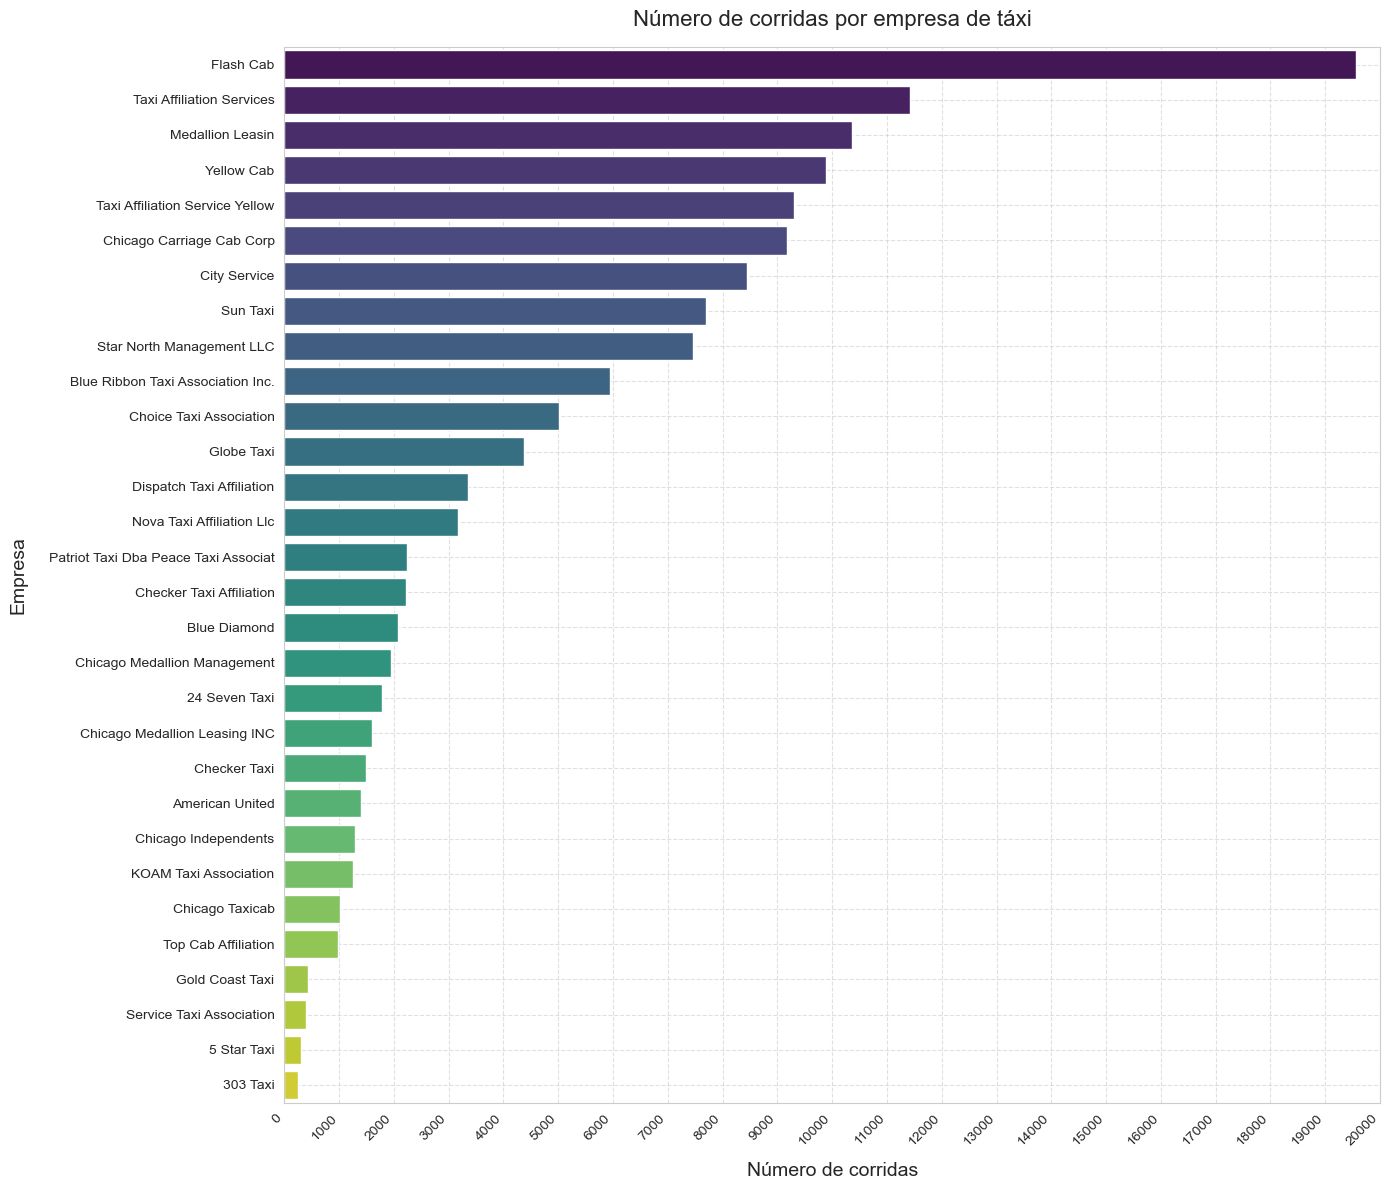

In [35]:
# Gráfico de barras horizontais para visualizar um ranking de empresas mais ativas

plt.figure(figsize=(14, 12))

sns.set_style('whitegrid')

sns.barplot(data=df_company_trips.head(30),
            x='trips_amount', 
            y='company_name', 
            palette='viridis')

plt.title('Número de corridas por empresa de táxi', fontsize=16, pad=15)
plt.xlabel('Número de corridas', fontsize=14, labelpad=10)
plt.ylabel('Empresa', fontsize=14, labelpad=15)

plt.xticks(range(0, 20001, 1000), rotation=45, ha='right')
plt.xlim(0, 20000)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
print()
plt.show()

In [36]:
# Para ilustrar melhor, vamos calcular o percentual de mercado para as 30 principais empresas

# Total de corridas de todas as empresas no dataset original
total_trips = df_company_trips['trips_amount'].sum()

# Calculando o percentual para as 30 principais empresas
top_30_companies = df_company_trips.head(30).copy()
top_30_companies['market_share'] = (top_30_companies['trips_amount'] / total_trips * 100).round(2)

# Criando uma tabela com os resultados
print('Análise de Market Share das 30 principais empresas de táxi')
print('-' * 60)
print(f'Total de empresas no dataset: {len(df_company_trips):,}')
print(f'Total de corridas no dataset: {total_trips:,}')
print(f"Total de corridas das top 30 empresas: {top_30_companies['trips_amount'].sum():,}")
print(f"Percentual do mercado coberto pelas top 30 empresas: {(top_30_companies['trips_amount'].sum() / total_trips * 100):.2f}%")
print('-' * 60)

# Exibindo tabela com empresa, número de corridas e percentual de mercado
result_table = top_30_companies[['company_name', 'trips_amount', 'market_share']]
result_table.columns = ['Empresa', 'Número de corridas', 'Market Share (%)']
display(result_table)

Análise de Market Share das 30 principais empresas de táxi
------------------------------------------------------------
Total de empresas no dataset: 64
Total de corridas no dataset: 137,311
Total de corridas das top 30 empresas: 135,885
Percentual do mercado coberto pelas top 30 empresas: 98.96%
------------------------------------------------------------


,Empresa,Número de corridas,Market Share (%)
0,Flash Cab,19558,14.24
1,Taxi Affiliation Services,11422,8.32
2,Medallion Leasin,10367,7.55
3,Yellow Cab,9888,7.20
4,Taxi Affiliation Service Yellow,9299,6.77
5,Chicago Carriage Cab Corp,9181,6.69
6,City Service,8448,6.15
7,Sun Taxi,7701,5.61
8,Star North Management LLC,7455,5.43
9,Blue Ribbon Taxi Association Inc.,5953,4.34


In [37]:
# Utilizando um gráfico lollipop para visualizar a distribuição de mercado

# Agrupando empresas menores para melhor visualização
threshold = 4.0  # Empresas com menos de 4% serão agrupadas como "Outras"
small_companies = result_table[result_table['Market Share (%)'] < threshold]
large_companies = result_table[result_table['Market Share (%)'] >= threshold]

# Criando dados para o gráfico
plot_data = large_companies.copy()

# Adicionando a categoria "Outras empresas" se houver empresas pequenas
if not small_companies.empty:
    other_share = small_companies['Market Share (%)'].sum()
    other_trips = small_companies['Número de corridas'].sum()
    other_row = pd.DataFrame({
        'Empresa': ['Outras empresas'],
        'Número de corridas': [other_trips],
        'Market Share (%)': [other_share]
    })
    plot_data = pd.concat([plot_data, other_row], ignore_index=True)

# Ordenando por market share para melhor visualização
plot_data = plot_data.sort_values('Market Share (%)', ascending=False)

# Criando lollipop chart
fig = go.Figure()

# Pontos (a "bola" do pirulito)
fig.add_trace(go.Scatter(
    x=plot_data['Market Share (%)'],
    y=plot_data['Empresa'],
    mode='markers+text',
    marker=dict(size=16, color=px.colors.qualitative.Safe[:len(plot_data)]),
    text=[f'{v:.1f}%' for v in plot_data['Market Share (%)']],
    textposition='middle right',
    textfont=dict(size=11)
))

# Linhas horizontais (o "cabo" do pirulito)
for _, row in plot_data.iterrows():
    fig.add_shape(
        type='line',
        x0=0, x1=row['Market Share (%)'],
        y0=row['Empresa'], y1=row['Empresa'],
        line=dict(color='lightgray', width=2)
    )

fig.update_layout(
    title={
        "text": "Market Share por Empresa de Táxi (%)",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 18}
    },
    xaxis_title="Market Share (%)",
    xaxis=dict(
        range=[0, plot_data['Market Share (%)'].max() + 12],  # espaço pro label %
        ticksuffix="%",
        showgrid=False
    ),
    yaxis=dict(automargin=True),
    showlegend=False,
    margin=dict(l=190, r=80, t=60, b=60)
)

fig.show()

### Conclusões sobre a concentração de mercado:

Após análise da relação entre empresas de táxi e número de corridas, observamos que a empresa Flash Cab domina o mercado, com 14.24% de todo o mercado e quase 2x a quantidade de corridas da empresa em segundo lugar e que 10 empresas juntas detêm mais de 70% do mercado.

## Top 10 bairros de destino

/var/folders/fs/3hy1lgmd3p79yftgf7gp8gqh0000gn/T/ipykernel_5940/1209522540.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




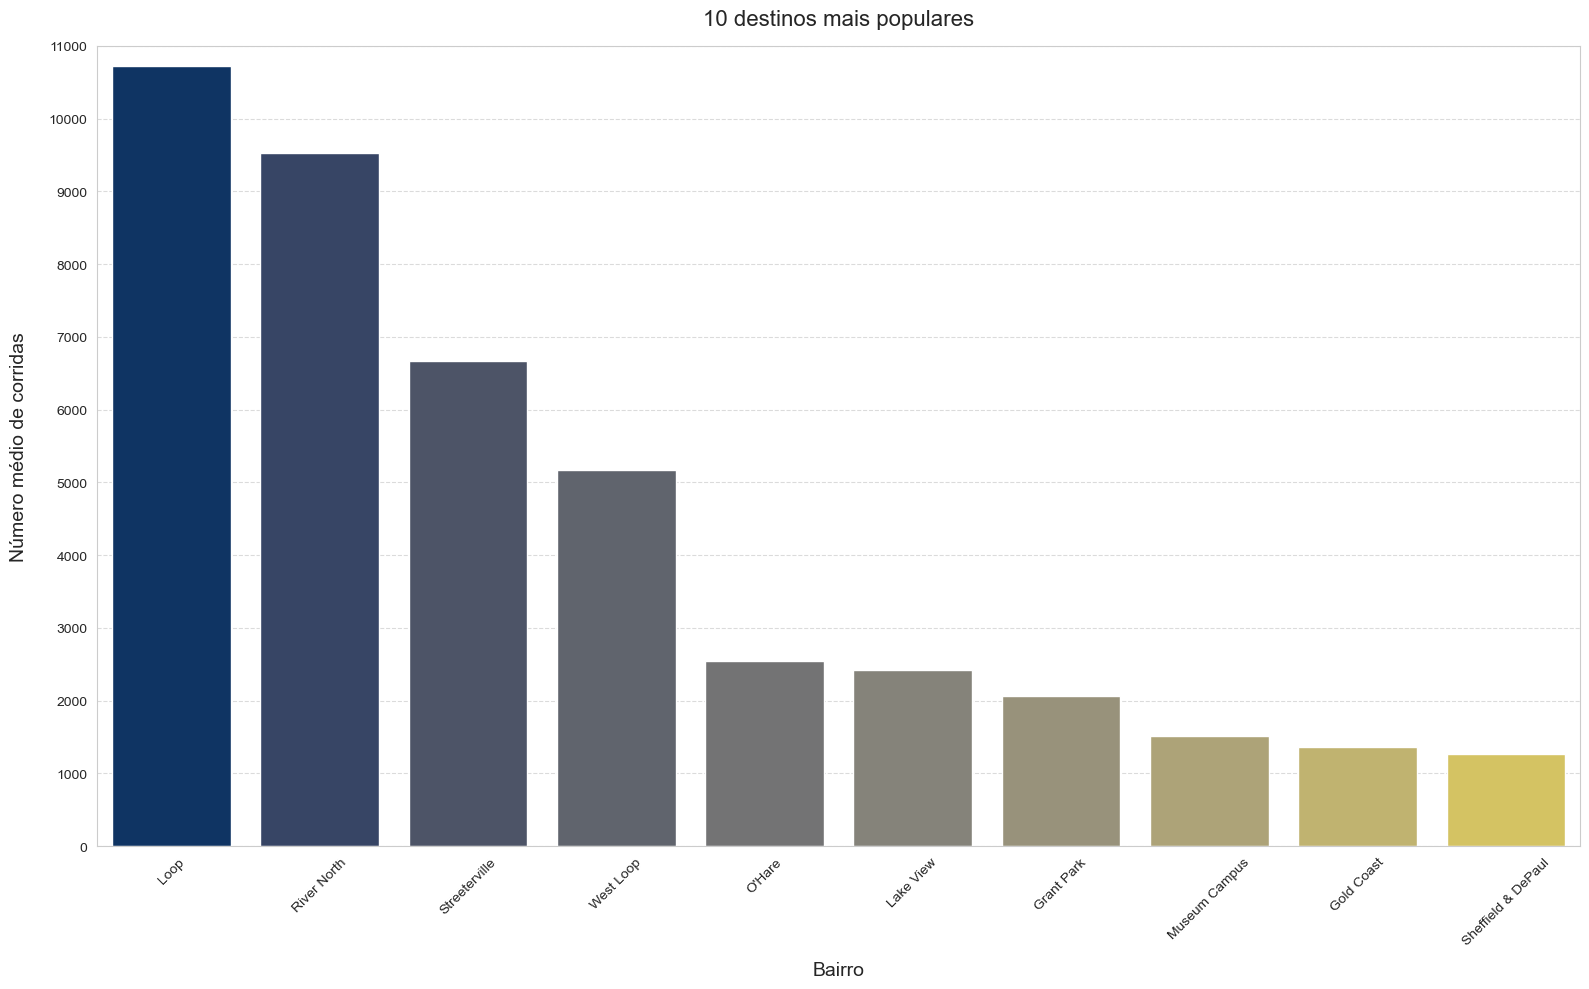

In [38]:

# Visualizando os destinos mais frequentes

plt.figure(figsize=(16, 10))

sns.set_style('whitegrid')

sns.barplot(data=df_top_10_locations, 
            x='dropoff_location_name', 
            y='average_trips', 
            palette='cividis')

plt.title('10 destinos mais populares', fontsize=16, pad=15)
plt.xlabel('Bairro', fontsize=14, labelpad=10)
plt.ylabel('Número médio de corridas', fontsize=14, labelpad=15)

plt.xticks(range(len(df_top_10_locations)), 
           df_top_10_locations['dropoff_location_name'], 
           rotation=45)

plt.yticks(range(0, 11001, 1000))
plt.ylim(0, 11000)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
print()
plt.show()



### Conclusões acerca dos destinos mais populares:

##### Esta análise dos 10 destinos mais populares fornece insights valiosos sobre os padrões de mobilidade urbana e pode orientar decisões estratégicas tanto para empresas de transporte quanto para planejadores urbanos, visando melhorar a eficiência do sistema de transporte e a qualidade de vida na cidade.

Após análise da relação entre a quantidade média de corridas e o destino destas corridas, podem observar:

**Concentração de demanda**:

- O gráfico demonstra uma clara concentração de demanda em poucos bairros específicos. Isso evidencia um desequilíbrio significativo na distribuição espacial das corridas de táxi, com alguns bairros atraindo um volume muito maior de viagens que outros.

**Implicações para o planejamento urbano**: 

- A alta concentração de viagens para determinados bairros pode indicar:

  - Possível sobrecarga da infraestrutura viária nesses locais
  - Necessidade de melhorias no transporte público para esses destinos
  - Oportunidades para desenvolvimento de mobilidade alternativa
   
**Implicações para empresas de táxi**: 

- As empresas podem otimizar o posicionamento de suas frotas próximo a esses destinos populares
- Estratégias de preços dinâmicos podem ser mais efetivas nesses locais de alta demanda
- Há oportunidades para serviços especializados nos bairros mais movimentados 

**Padrão de uso da cidade**: 

- O gráfico revela como os habitantes e visitantes utilizam o espaço urbano, destacando os principais polos de atração da cidade. Isso reflete a estrutura funcional da cidade, mostrando onde se concentram as atividades econômicas e sociais.

## Teste de hipótese:
### A duração média das viagens entre Loop e o Aeroporto Internacional de O'Hare é diferente em sábados chuvosos?

In [39]:
csv_path3 = os.path.join(os.getcwd(), 'project_sql_result_07.csv')
df_trips_to_airport = pd.read_csv(csv_path3)

In [40]:
# Visualizando df_trips_to_airport

title = 'Trips between Loop & O\'Hare Airport'
print('\n' + title.center(55))

display(df_trips_to_airport)

print()
df_trips_to_airport.info()


          Trips between Loop & O'Hare Airport          


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
...,...,...,...
1063,2017-11-25 11:00:00,Good,0.0
1064,2017-11-11 10:00:00,Good,1318.0
1065,2017-11-11 13:00:00,Good,2100.0
1066,2017-11-11 08:00:00,Good,1380.0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


In [41]:
# Convertendo timestamp para datetime e extraindo dia da semana
df_trips_to_airport['start_ts'] = pd.to_datetime(df_trips_to_airport['start_ts'])
df_trips_to_airport['day_of_week'] = df_trips_to_airport['start_ts'].dt.day_name()

# Verificando valores únicos das condições climáticas
print('Condições climáticas disponíveis:')
print(df_trips_to_airport['weather_conditions'].unique())

# Verificando dias da semana
print('\nDias da semana disponíveis:')
print(df_trips_to_airport['day_of_week'].unique())

Condições climáticas disponíveis:
['Good' 'Bad']

Dias da semana disponíveis:
['Saturday']


In [42]:
# Grupo 1: Sábados chuvosos
rainy_sat = df_trips_to_airport[
    (df_trips_to_airport['day_of_week'] == 'Saturday') & 
    (df_trips_to_airport['weather_conditions'] == 'Bad')
]['duration_seconds']

# Grupo 2: Outros períodos (sábados não-chuvosos)
others = df_trips_to_airport[
    ~((df_trips_to_airport['day_of_week'] == 'Saturday') & 
      (df_trips_to_airport['weather_conditions'] == 'Bad'))
]['duration_seconds']

# Realizando teste t
alpha = .05
statistic, p_value = st.ttest_ind(rainy_sat, others, equal_var=False)

print('\nTeste de hipóteses:')
print(f'Estatística t: {statistic:.4f}')
print(f'Valor_p: {p_value:.4f}')
print(f'Nível de significância: α = {alpha}')

print('\nEstatísticas descritivas:')
print(f'Rainy Saturdays - Desvio padrão: {rainy_sat.std():.2f}')
print(f'Others  - Desvio padrão: {others.std():.2f}')

if p_value < alpha:
    print('\nOs dados nos dão motivos para rejeitar a hipótese nula: '
          'as médias são estatisticamente diferentes.')
else:
    print('\nOs dados não nos dão motivos para rejeitar a hipótese nula: '
          'não há evidência de diferença estatística entre as médias.')


Teste de hipóteses:
Estatística t: 7.1860
Valor_p: 0.0000
Nível de significância: α = 0.05

Estatísticas descritivas:
Rainy Saturdays - Desvio padrão: 721.31
Others  - Desvio padrão: 759.20

Os dados nos dão motivos para rejeitar a hipótese nula: as médias são estatisticamente diferentes.


#### Conclusões

**Sobre a escolha do nível de significância (α =.05):**

- Respeita um padrão científico amplamente aceito

- Estabelece um equilíbrio razoável entre erros Tipo I (rejeitar H₀ quando ela é verdadeira - falso positivo) e Tipo II (não rejeitar H₀ quando ela é falsa - falso negativo)

- Apropriada para análise de negócios

**Escolha do teste estatístico:**

Teste t de Student para duas amostras independentes, pois:

- Optei por testes bilaterais porque o objetivo era detectar qualquer diferença entre as médias das viagens, sem uma expectativa prévia no fato de clima atuar ou não sobre o tempo da corrida

- Foram comparadas duas médias de grupos independentes (sábados chuvosos vs. não chuvosos)

- Variâncias podem ser diferentes (uso do teste de Welch com equal_var=False)

**Formulação das hipóteses:**
 
Hipótese Nula (H₀):

 - H₀: μ_sábados_chuvosos = μ_outros_períodos

   - 'A duração média dos passeios do Loop para O'Hare NÃO muda nos sábados chuvosos'


Hipótese Alternativa (H₁):

 - H₁: μ_sábados_chuvosos ≠ μ_outros_períodos

   - 'A duração média dos passeios do Loop para O'Hare muda nos sábados chuvosos'
 
**Força da evidência:**

- P-valor ≈ 0: Probabilidade quase nula de observar essa diferença se H₀ fosse verdadeira

- Estatística t alta: Indica diferença muito significativa entre os grupos

**Significância prática:**

- A diferença não é apenas estatisticamente significativa, mas provavelmente também praticamente relevante

- Importante para planejamento de viagens e precificação

**Confiabilidade:**

- Teste bilateral: Detecta diferenças em qualquer direção

- Welch's t-test (equal_var=False): Apropriado quando os desvios padrão são diferentes

#### Para entender se as viagens ficam mais longas ou mais curtas, vamos calcular as médias

In [43]:
print(f'\nDuração média - Sábados chuvosos: {rainy_sat.mean():.2f} segundos')

print(f'\nDuração média - Sábados bom tempo: {others.mean():.2f} segundos')

print(f'\nDiferença: {rainy_sat.mean() - others.mean():.2f} segundos')


Duração média - Sábados chuvosos: 2427.21 segundos

Duração média - Sábados bom tempo: 1999.68 segundos

Diferença: 427.53 segundos



### Interpretação dos resultados:


**Conclusão estatística:**

Rejeitamos H₀ com alta confiança (p-valor ≈ 0.0000)

Há evidência estatística muito forte de que a duração média das viagens muda nos sábados chuvosos.


**Conclusão prática:**

- Sábados chuvosos: 2.427 segundos (≈ 40,5 minutos)

- Outros períodos: 1.999 segundos (≈ 33,3 minutos)

- Diferença: +427 segundos (≈ 7,1 minutos a mais)

As viagens ficam **mais longas** nos sábados chuvosos


**Magnitude do efeito:**

A diferença representa um aumento de 21,4% na duração da viagem:

(2427.21 - 1999.68) / 1999.68 × 100% = 21,4%

- *Por que isso acontece?*

    
    Explicações lógicas:

  - Trânsito mais lento: chuva reduz velocidade de condução

  - Maior demanda: mais pessoas preferem táxi em dias chuvosos

  - Rotas alternativas: motoristas podem escolher caminhos mais seguros

  - Condições de direção: visibilidade reduzida, maior cautela


**Implicações práticas:**

- Para passageiros:

  - Planejar tempo extra em sábados chuvosos (+7 minutos)

  - Considerar custos adicionais se cobrança for por tempo

- *Para empresas de táxi:*

  - Ajustar preços dinâmicos em dias chuvosos

  - Otimizar frota para demanda aumentada

  - Comunicar tempos estimados mais realistas

**Força da evidência:**

   *Muito alta* porque:

  - P-valor praticamente zero

  - Estatística t = 7.19 (muito acima do limiar de significância)

  - Diferença prática relevante (7+ minutos)